# **Modelling LSTM v2 — Fair Comparison vs Random Forest**

Notebook ini mengimplementasikan perbaikan struktural berdasarkan review kode LSTM sebelumnya. Tujuannya: membuat perbandingan yang **fair** terhadap Random Forest perbaikan (RF dapat 7 fitur lag/rolling eksplisit, LSTM tidak — itu yang dibetulkan di sini).

**Daftar perbaikan vs versi lama:**

| Kode | Perbaikan | Implementasi |
|------|-----------|--------------|
| A1 | Tambah fitur lag/rolling PM2.5 | 7 fitur (pm25_lag_1/3/7 + rolling mean/max/std) ikut sebagai **static input** post-LSTM |
| A2 | Multi-input architecture | Functional API: sequence input → LSTM; static input → Dense; concat → output |
| A3 | Median imputation no leakage | Median dihitung hanya di TRAIN, dipakai untuk val & test |
| A5 | y-scaling konsisten | Tuning maupun retrain final pakai pola scaler yang sama (StandardScaler fit train) |
| B4 | Tuning lebih luas | Optuna: lookback ∈ {7,14,21,30}, units, dropout, batch, L2, jumlah layer |

**Konvensi yang dipatuhi:**
- Dataset proposal scope v1 (`dataset_final_model.csv`, 6 cuaca).
- Time-based 70/15/15 train/val/test split.
- Model selection by **lowest val_RMSE**; test set dipakai sekali di akhir.
- Final model di-retrain pada **train + validation**.
- Output baru pakai suffix `_lstm_v2` — file lama tetap utuh.

**Catatan target leakage:** LSTM memakai PM2.5 sebagai **history** (t-L..t-1), bukan sebagai target hari-H. Sequence builder pakai `arr[i-lookback:i]` (i di-exclude), sehingga nilai aktual hari-H **tidak pernah** ada di input.


## 1. Setup & Imports

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import json, time, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score,
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

RANDOM = 42
random.seed(RANDOM); np.random.seed(RANDOM)
tf.keras.utils.set_random_seed(RANDOM)
print('TF', tf.__version__, '| Keras', keras.__version__)


TF 2.21.0 | Keras 3.14.0


In [3]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'final for modelling' / 'dataset_final_model.csv'
DIR_OUTPUT = PROJECT_ROOT / 'notebooks' / 'outputs'
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH, parse_dates=['tanggal'])
TARGET = 'ISPU PM2.5'
print('Dataset :', DATA_PATH)
print('Shape   :', df_raw.shape)
print('Tanggal :', df_raw['tanggal'].min().date(), '->', df_raw['tanggal'].max().date())
display(df_raw.head(3))


Dataset : c:\Users\User\Air Pollution - Daming Project\data\final for modelling\dataset_final_model.csv
Shape   : (7679, 18)
Tanggal : 2022-01-01 -> 2025-01-01


,tanggal,ISPU PM2.5,kategori_pm25,bulan,hari_minggu,temp,humidity,visibility,windgust,solarenergy,precip,station_bundaran hi,station_jagakarsa,station_kebun jeruk,station_kelapa gading,station_lubang buaya,station_us embassy 1,station_us embassy 2
0,2022-01-01,74.0,Sedang,1,5,28.6,77.2,6.7,37.1,20.6,0.496,1,0,0,0,0,0,0
1,2022-01-01,73.0,Sedang,1,5,28.3,77.8,6.8,37.1,20.6,0.502,0,1,0,0,0,0,0
2,2022-01-01,71.0,Sedang,1,5,28.3,79.3,7.5,37.1,20.6,0.645,0,0,1,0,0,0,0


## 2. Feature Engineering

Konsisten dengan RF perbaikan: 6 cuaca proposal + 7 lag/rolling PM2.5 + 4 siklikal + musim Jakarta + station one-hot.

In [4]:
KOLOM_CUACA = ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']
sc_cols = [c for c in df_raw.columns if c.startswith('station_')]
if not sc_cols:
    raise ValueError('Kolom one-hot station_ tidak ditemukan.')

data = df_raw.copy()
data['tanggal'] = pd.to_datetime(data['tanggal'])

# Buang baris tanpa data cuaca sama sekali (e.g., 2025-01-01)
mask_no_cuaca = data[KOLOM_CUACA].isna().all(axis=1)
print(f'Baris tanpa cuaca yang dibuang: {int(mask_no_cuaca.sum())}')
data = data[~mask_no_cuaca].reset_index(drop=True)

# Rekonstruksi nama stasiun
data['station'] = data[sc_cols].idxmax(axis=1).str.replace('station_', '', regex=False)

if 'bulan' not in data.columns:
    data['bulan'] = data['tanggal'].dt.month
if 'hari_minggu' not in data.columns:
    data['hari_minggu'] = data['tanggal'].dt.dayofweek

# Urut per stasiun & tanggal untuk lag konsisten
data = data.sort_values(['station', 'tanggal']).reset_index(drop=True)

# Fitur lag PM2.5 per stasiun
for lag in [1, 3, 7]:
    data[f'pm25_lag_{lag}'] = data.groupby('station')[TARGET].shift(lag)

# Fitur rolling per stasiun (selalu shift(1) dulu agar tidak include hari-H)
pm25_prev = data.groupby('station')[TARGET].shift(1)
def _roll(s, w, f):
    return s.groupby(data['station']).rolling(w).agg(f).reset_index(level=0, drop=True)
data['pm25_rolling_mean_3'] = _roll(pm25_prev, 3, 'mean')
data['pm25_rolling_mean_7'] = _roll(pm25_prev, 7, 'mean')
data['pm25_rolling_max_7']  = _roll(pm25_prev, 7, 'max')
data['pm25_rolling_std_7']  = _roll(pm25_prev, 7, 'std')

FITUR_LAG_ROLLING = ['pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7',
                     'pm25_rolling_mean_3', 'pm25_rolling_mean_7',
                     'pm25_rolling_max_7', 'pm25_rolling_std_7']

# Siklikal waktu
data['bulan_sin']      = np.sin(2 * np.pi * data['bulan'] / 12)
data['bulan_cos']      = np.cos(2 * np.pi * data['bulan'] / 12)
data['hari_minggu_sin'] = np.sin(2 * np.pi * data['hari_minggu'] / 7)
data['hari_minggu_cos'] = np.cos(2 * np.pi * data['hari_minggu'] / 7)

# Musim Jakarta (konsisten RF): Hujan=Nov-Mar, Transisi=April, Kemarau=Mei-Okt
def _musim(b):
    if b in (11, 12, 1, 2, 3): return 'Hujan'
    if b == 4: return 'Transisi'
    return 'Kemarau'
data['musim'] = data['bulan'].map(_musim)
musim_dummies = pd.get_dummies(data['musim'], prefix='musim').astype(float)
for col in ['musim_Hujan', 'musim_Kemarau', 'musim_Transisi']:
    if col not in musim_dummies.columns: musim_dummies[col] = 0.0
musim_cols = ['musim_Hujan', 'musim_Kemarau', 'musim_Transisi']
for c in musim_cols:
    data[c] = musim_dummies[c].values

# Drop baris NaN akibat lag/rolling (awal periode tiap stasiun)
sebelum = len(data)
data = data.dropna(subset=FITUR_LAG_ROLLING).reset_index(drop=True)
print(f'Baris setelah drop NaN lag/rolling: {len(data)} (dibuang {sebelum - len(data)})')

# Sort balik (tanggal, station) untuk split waktu
data = data.sort_values(['tanggal', 'station']).reset_index(drop=True)
display(data[['tanggal', 'station', TARGET] + FITUR_LAG_ROLLING].head(8))


Baris tanpa cuaca yang dibuang: 7
Baris setelah drop NaN lag/rolling: 7623 (dibuang 49)


,tanggal,station,ISPU PM2.5,pm25_lag_1,pm25_lag_3,pm25_lag_7,pm25_rolling_mean_3,pm25_rolling_mean_7,pm25_rolling_max_7,pm25_rolling_std_7
0,2022-01-08,bundaran hi,58.579848,75.711602,74.000000,74.000000,74.744893,74.319240,75.711602,0.644178
1,2022-01-08,jagakarsa,59.315727,76.051621,73.000000,73.000000,74.205455,73.516624,76.051621,1.137470
2,2022-01-08,kebun jeruk,58.729425,76.141752,71.000000,71.000000,72.929944,71.827119,76.141752,1.917844
3,2022-01-08,kelapa gading,59.207592,75.461940,74.973893,74.973893,75.297409,75.112543,75.461940,0.236794
4,2022-01-08,lubang buaya,58.985369,77.764604,80.000000,80.000000,79.345894,79.719669,80.273079,0.868089
5,2022-01-08,us embassy 1,58.667845,80.154021,70.284673,70.284673,73.800417,71.791421,80.154021,3.696204
6,2022-01-08,us embassy 2,60.124441,76.467050,77.250157,77.250157,77.118340,77.193664,77.637812,0.351471
7,2022-01-09,bundaran hi,72.112494,58.579848,74.523079,74.000000,69.604843,72.116361,75.711602,6.002050


## 3. Definisi Fitur: Sequence vs Static

**Sequence input** (berubah tiap timestep, ikut LSTM):
- `TARGET` (PM2.5 history)
- 6 cuaca
- 4 siklikal

**Static input** (konstan untuk satu window, diambil dari snapshot hari prediksi t — concat ke output LSTM):
- 7 lag/rolling PM2.5 (engineered features yang membantu LSTM converge)
- 7 station one-hot
- 3 musim one-hot

Ini menjawab perbaikan **A1** (lag/rolling fairness) dan **A2** (jangan boroskan channel sequence untuk fitur konstan).

In [5]:
FITUR_SEQUENCE = [TARGET] + KOLOM_CUACA + ['bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos']
FITUR_STATIC  = FITUR_LAG_ROLLING + sc_cols + musim_cols

print(f'#fitur sequence : {len(FITUR_SEQUENCE)} -> {FITUR_SEQUENCE}')
print(f'#fitur static   : {len(FITUR_STATIC)} -> {FITUR_STATIC[:5]} ... ({len(FITUR_STATIC)-5} lainnya)')


#fitur sequence : 11 -> ['ISPU PM2.5', 'temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip', 'bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos']
#fitur static   : 17 -> ['pm25_lag_1', 'pm25_lag_3', 'pm25_lag_7', 'pm25_rolling_mean_3', 'pm25_rolling_mean_7'] ... (12 lainnya)


## 4. Time-Based Split 70/15/15

Split berbasis tanggal unik supaya tidak ada kebocoran lintas hari.

In [6]:
tanggal_unik = np.array(sorted(data['tanggal'].unique()))
n = len(tanggal_unik)
BATAS_TRAIN = pd.Timestamp(tanggal_unik[int(n * 0.70)])
BATAS_VAL   = pd.Timestamp(tanggal_unik[int(n * 0.85)])

mask_tr = data['tanggal'] < BATAS_TRAIN
mask_va = (data['tanggal'] >= BATAS_TRAIN) & (data['tanggal'] < BATAS_VAL)
mask_te = data['tanggal'] >= BATAS_VAL

info = pd.DataFrame([
    {'subset': 'Train', 'baris': int(mask_tr.sum()),
     'mulai': data.loc[mask_tr, 'tanggal'].min().date(),
     'akhir': data.loc[mask_tr, 'tanggal'].max().date()},
    {'subset': 'Validation', 'baris': int(mask_va.sum()),
     'mulai': data.loc[mask_va, 'tanggal'].min().date(),
     'akhir': data.loc[mask_va, 'tanggal'].max().date()},
    {'subset': 'Test', 'baris': int(mask_te.sum()),
     'mulai': data.loc[mask_te, 'tanggal'].min().date(),
     'akhir': data.loc[mask_te, 'tanggal'].max().date()},
])
print(f'Train < {BATAS_TRAIN.date()} | Val < {BATAS_VAL.date()} | Test >= {BATAS_VAL.date()}')
display(info)


Train < 2024-02-09 | Val < 2024-07-21 | Test >= 2024-07-21


,subset,baris,mulai,akhir
0,Train,5334,2022-01-08,2024-02-08
1,Validation,1141,2024-02-09,2024-07-20
2,Test,1148,2024-07-21,2024-12-31


## 5. Imputation Median: Fit Train Only

**Perbaikan A3.** Versi LSTM lama melakukan `groupby('station').transform(fillna(median))` lintas seluruh data → bocor info val/test ke train. Di sini median dihitung **hanya dari train**, lalu dipakai untuk val/test.

In [7]:
data_clean = data.copy()

cols_to_impute = [c for c in FITUR_SEQUENCE + FITUR_STATIC if c in data_clean.columns]
na_before = data_clean[cols_to_impute].isna().sum().sum()

# Median dari TRAIN saja
med_train = data_clean.loc[mask_tr, cols_to_impute].median(numeric_only=True)
for c in cols_to_impute:
    if data_clean[c].isna().any():
        data_clean[c] = data_clean[c].fillna(med_train[c])

na_after = data_clean[cols_to_impute].isna().sum().sum()
print(f'NaN sebelum impute : {int(na_before)}  ->  sesudah : {int(na_after)}')
print('Sumber median: TRAIN only (no leakage)')


NaN sebelum impute : 0  ->  sesudah : 0
Sumber median: TRAIN only (no leakage)


## 6. Multi-Input Sequence Builder

Untuk tiap baris valid (i >= lookback), bangun:
- `X_seq[i]` = matriks (lookback, n_seq_feat) dari `arr_seq[i-lookback:i]` (hari-H di-exclude).
- `X_static[i]` = vektor (n_static_feat,) diambil dari snapshot hari-H (lag/rolling sudah dihitung dari hari-H ke belakang dengan shift, jadi aman).
- `y[i]` = PM2.5 hari-H.


In [8]:
def bangun_multi_input(df, fitur_seq, fitur_static, target, lookback, stasiun_col='station'):
    Xs_list, Xst_list, y_list, tgl_list, st_list = [], [], [], [], []
    for st, sub in df.groupby(stasiun_col):
        sub = sub.sort_values('tanggal').reset_index(drop=True)
        if len(sub) <= lookback:
            continue
        arr_seq = sub[fitur_seq].values.astype(np.float32)
        arr_st  = sub[fitur_static].values.astype(np.float32)
        y_arr   = sub[target].values.astype(np.float32)
        tgl     = sub['tanggal'].values
        for i in range(lookback, len(sub)):
            Xs_list.append(arr_seq[i - lookback:i])  # exclude i -> hari-H aman
            Xst_list.append(arr_st[i])
            y_list.append(y_arr[i])
            tgl_list.append(tgl[i])
            st_list.append(st)
    return (np.stack(Xs_list),
            np.stack(Xst_list),
            np.array(y_list, dtype=np.float32),
            pd.to_datetime(np.array(tgl_list)),
            np.array(st_list))


# Smoke test dengan lookback=14
X_seq_14, X_static_14, y_14, tgl_14, st_14 = bangun_multi_input(
    data_clean, FITUR_SEQUENCE, FITUR_STATIC, TARGET, lookback=14)
print(f'X_seq    : {X_seq_14.shape}  (N, L, n_seq_feat)')
print(f'X_static : {X_static_14.shape}  (N, n_static_feat)')
print(f'y        : {y_14.shape}')
print(f'Tanggal target: {tgl_14.min().date()} -> {tgl_14.max().date()}')


X_seq    : (7525, 14, 11)  (N, L, n_seq_feat)
X_static : (7525, 17)  (N, n_static_feat)
y        : (7525,)
Tanggal target: 2022-01-22 -> 2024-12-31


## 7. Scaling Konsisten (Fit Train Only)

**Perbaikan A5.** Scaler X (sequence + static) dan scaler y di-fit hanya pada bagian train, dipakai untuk semua subset. Pola yang sama akan dipakai juga pada saat retrain (train+val) di section akhir.

In [9]:
def split_masks_by_date(tanggal_arr):
    m_tr = tanggal_arr < BATAS_TRAIN
    m_va = (tanggal_arr >= BATAS_TRAIN) & (tanggal_arr < BATAS_VAL)
    m_te = tanggal_arr >= BATAS_VAL
    return m_tr, m_va, m_te


def buat_scalers(X_seq_tr, X_static_tr, y_tr):
    F_seq = X_seq_tr.shape[2]
    sx_seq = StandardScaler().fit(X_seq_tr.reshape(-1, F_seq))
    sx_static = StandardScaler().fit(X_static_tr)
    sy = StandardScaler().fit(y_tr.reshape(-1, 1))
    return sx_seq, sx_static, sy


def apply_scaling(X_seq, X_static, y, sx_seq, sx_static, sy=None):
    F_seq = X_seq.shape[2]
    X_seq_s    = sx_seq.transform(X_seq.reshape(-1, F_seq)).reshape(X_seq.shape).astype(np.float32)
    X_static_s = sx_static.transform(X_static).astype(np.float32)
    y_s = sy.transform(y.reshape(-1, 1)).ravel().astype(np.float32) if sy is not None else y
    return X_seq_s, X_static_s, y_s


print('Helpers scaling siap.')


Helpers scaling siap.


## 8. Multi-Input Model Architectures

**Perbaikan A2.** Functional API: 2 input branches → concat → dense → output.
- **A**: 1-layer LSTM kecil (64) + static dense (16) + head 32.
- **B**: 1-layer LSTM besar (128) + static dense (32) + head 64, dropout lebih tinggi.
- **C**: 2-layer LSTM (64→32) + static dense (16) + head 32.

In [10]:
def build_multi_input(lookback, n_seq, n_static, *, lstm_units=(64,), static_units=16, head_units=32,
                      dropout=0.2, l2=1e-4, lr=1e-3, batchnorm=False):
    seq_in = layers.Input(shape=(lookback, n_seq), name='sequence')
    x = seq_in
    for i, u in enumerate(lstm_units):
        return_seq = (i < len(lstm_units) - 1)
        x = layers.LSTM(u, return_sequences=return_seq, dropout=dropout,
                        kernel_regularizer=regularizers.l2(l2))(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)

    static_in = layers.Input(shape=(n_static,), name='static')
    s = layers.Dense(static_units, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(static_in)
    if batchnorm:
        s = layers.BatchNormalization()(s)

    h = layers.Concatenate()([x, s])
    h = layers.Dense(head_units, activation='relu',
                     kernel_regularizer=regularizers.l2(l2))(h)
    h = layers.Dropout(dropout)(h)
    out = layers.Dense(1)(h)

    model = keras.Model(inputs=[seq_in, static_in], outputs=out, name='lstm_multi_input')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model


def arch_A(L, ns, nst): return build_multi_input(L, ns, nst, lstm_units=(64,),    static_units=16, head_units=32, dropout=0.2, l2=1e-4)
def arch_B(L, ns, nst): return build_multi_input(L, ns, nst, lstm_units=(128,),   static_units=32, head_units=64, dropout=0.3, l2=1e-4)
def arch_C(L, ns, nst): return build_multi_input(L, ns, nst, lstm_units=(64, 32), static_units=16, head_units=32, dropout=0.2, l2=1e-4)

# Smoke test ringkas
_demo = arch_A(14, len(FITUR_SEQUENCE), len(FITUR_STATIC))
_demo.summary()


Model: "lstm_multi_input"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 14, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static (InputLayer) │ (None, 17)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        288 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,369 (87.38 KB)

 Trainable params: 22,369 (87.38 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Metrik & Fungsi Bantu Evaluasi

In [11]:
def mape_aman(y, p, epsilon=1.0):
    y = np.asarray(y, float); p = np.asarray(p, float)
    m = np.abs(y) > epsilon
    return float(np.mean(np.abs((y[m] - p[m]) / y[m])) * 100) if m.sum() else np.nan


def metrik_regresi(y, p):
    return {'MAE': float(mean_absolute_error(y, p)),
            'RMSE': float(mean_squared_error(y, p) ** 0.5),
            'R2': float(r2_score(y, p)),
            'MAPE': mape_aman(y, p)}


URUTAN_KATEGORI_ISPU = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
def ke_kategori_ispu(v):
    if v <= 50: return 'Baik'
    if v <= 100: return 'Sedang'
    if v < 200: return 'Tidak Sehat'
    if v < 300: return 'Sangat Tidak Sehat'
    return 'Berbahaya'


def recall_tidak_sehat(y, p):
    ka = pd.Series(np.asarray(y)).map(ke_kategori_ispu)
    kp = pd.Series(np.asarray(p)).map(ke_kategori_ispu)
    return float(recall_score(ka, kp, labels=['Tidak Sehat'], average='macro', zero_division=0))


print('Fungsi evaluasi siap.')


Fungsi evaluasi siap.


## 10. Runner Eksperimen LSTM v2

Membungkus: bangun sequence → split → scale (fit train) → train → evaluasi val. Dipakai untuk eksperimen awal **dan** Optuna.

In [12]:
def jalankan_eksperimen(label, factory, lookback, *, df_lokal=data_clean,
                        epochs=120, batch_size=64, patience=15, verbose=0, return_full=False):
    X_seq, X_static, y, tanggal, stasiun = bangun_multi_input(
        df_lokal, FITUR_SEQUENCE, FITUR_STATIC, TARGET, lookback)
    m_tr, m_va, m_te = split_masks_by_date(tanggal)

    sx_seq, sx_static, sy = buat_scalers(X_seq[m_tr], X_static[m_tr], y[m_tr])
    Xs_tr, Xst_tr, ys_tr = apply_scaling(X_seq[m_tr], X_static[m_tr], y[m_tr], sx_seq, sx_static, sy)
    Xs_va, Xst_va, ys_va = apply_scaling(X_seq[m_va], X_static[m_va], y[m_va], sx_seq, sx_static, sy)
    Xs_te, Xst_te, _     = apply_scaling(X_seq[m_te], X_static[m_te], y[m_te], sx_seq, sx_static)

    def inv(p): return sy.inverse_transform(p.reshape(-1, 1)).ravel()

    tf.keras.utils.set_random_seed(RANDOM)
    model = factory(lookback, len(FITUR_SEQUENCE), len(FITUR_STATIC))
    cb = [keras.callbacks.EarlyStopping(patience=patience, monitor='val_loss',
                                        restore_best_weights=True, verbose=0),
          keras.callbacks.ReduceLROnPlateau(patience=max(3, patience // 2), factor=0.5,
                                            min_lr=1e-5, monitor='val_loss', verbose=0)]
    t0 = time.time()
    hist = model.fit({'sequence': Xs_tr, 'static': Xst_tr}, ys_tr,
                     validation_data=({'sequence': Xs_va, 'static': Xst_va}, ys_va),
                     epochs=epochs, batch_size=batch_size, verbose=verbose, callbacks=cb)
    waktu = time.time() - t0
    epoch_best = int(np.argmin(hist.history['val_loss'])) + 1

    pv = inv(model.predict({'sequence': Xs_va, 'static': Xst_va}, verbose=0))
    pt = inv(model.predict({'sequence': Xs_te, 'static': Xst_te}, verbose=0))
    yv_real, yt_real = y[m_va], y[m_te]

    hasil = {
        'label': label, 'lookback': lookback,
        'val_metrik': metrik_regresi(yv_real, pv),
        'test_metrik': metrik_regresi(yt_real, pt),
        'recall_ts_test': recall_tidak_sehat(yt_real, pt),
        'epoch_best': epoch_best, 'waktu_detik': round(waktu, 1),
        'yt_real': yt_real, 'pt': pt, 'yv_real': yv_real, 'pv': pv,
        'tanggal_test': tanggal[m_te], 'stasiun_test': stasiun[m_te],
    }
    if return_full:
        hasil.update({'model': model, 'hist': hist,
                      'scaler_seq': sx_seq, 'scaler_static': sx_static, 'scaler_y': sy,
                      'masks': (m_tr, m_va, m_te),
                      'X_seq_all': X_seq, 'X_static_all': X_static, 'y_all': y, 'tanggal_all': tanggal})
    return hasil


print('Runner siap.')


Runner siap.


## 11. Eksperimen Awal — 3 Arsitektur × 3 Lookback

Sebelum Optuna, jalankan kombinasi sederhana (3 arch × 3 lookback = 9 run) untuk mendapat baseline. Sortir akhir by **val_RMSE**.

In [13]:
eksperimen_awal = {}
GRID_AWAL = [
    ('A_LSTM64',          arch_A),
    ('B_LSTM128',         arch_B),
    ('C_LSTM64+32',       arch_C),
]
LOOKBACKS_AWAL = [7, 14, 21]

for nm, fac in GRID_AWAL:
    for L in LOOKBACKS_AWAL:
        label = f'{nm} (L{L})'
        res = jalankan_eksperimen(label, fac, L, verbose=0)
        eksperimen_awal[label] = res
        print(f'{label:25s} ep{res["epoch_best"]:3d} | val_RMSE {res["val_metrik"]["RMSE"]:6.3f} | '
              f'test_RMSE {res["test_metrik"]["RMSE"]:6.3f} R2 {res["test_metrik"]["R2"]:.3f} | '
              f'recall_TS {res["recall_ts_test"]:.4f} | {res["waktu_detik"]}s')

tabel_awal = pd.DataFrame([
    {'model': k, 'lookback': v['lookback'],
     'val_RMSE': round(v['val_metrik']['RMSE'], 4),
     'test_RMSE': round(v['test_metrik']['RMSE'], 4),
     'test_R2': round(v['test_metrik']['R2'], 4),
     'test_MAE': round(v['test_metrik']['MAE'], 4),
     'recall_TS': round(v['recall_ts_test'], 4),
     'epoch_best': v['epoch_best'], 'waktu_detik': v['waktu_detik']}
    for k, v in eksperimen_awal.items()
]).sort_values('val_RMSE').reset_index(drop=True)
tabel_awal.to_csv(DIR_OUTPUT / 'hasil_eksperimen_lstm_v2_awal.csv', index=False)
display(tabel_awal)


A_LSTM64 (L7)             ep  6 | val_RMSE 11.993 | test_RMSE 13.097 R2 0.629 | recall_TS 0.0548 | 21.3s
A_LSTM64 (L14)            ep 11 | val_RMSE 11.910 | test_RMSE 12.912 R2 0.640 | recall_TS 0.0548 | 34.2s
A_LSTM64 (L21)            ep 14 | val_RMSE 11.927 | test_RMSE 12.945 R2 0.638 | recall_TS 0.0411 | 45.5s
B_LSTM128 (L7)            ep  5 | val_RMSE 11.801 | test_RMSE 12.753 R2 0.649 | recall_TS 0.0959 | 25.9s
B_LSTM128 (L14)           ep 11 | val_RMSE 11.761 | test_RMSE 12.745 R2 0.649 | recall_TS 0.2055 | 47.8s
B_LSTM128 (L21)           ep  9 | val_RMSE 11.961 | test_RMSE 12.721 R2 0.650 | recall_TS 0.0959 | 56.3s
C_LSTM64+32 (L7)          ep 12 | val_RMSE 11.883 | test_RMSE 12.977 R2 0.636 | recall_TS 0.0411 | 36.1s
C_LSTM64+32 (L14)         ep 12 | val_RMSE 11.855 | test_RMSE 12.858 R2 0.643 | recall_TS 0.0548 | 51.5s
C_LSTM64+32 (L21)         ep 13 | val_RMSE 12.007 | test_RMSE 13.260 R2 0.620 | recall_TS 0.0411 | 64.4s


,model,lookback,val_RMSE,test_RMSE,test_R2,test_MAE,recall_TS,epoch_best,waktu_detik
0,B_LSTM128 (L14),14,11.7610,12.7453,0.6491,9.0941,0.2055,11,47.8
1,B_LSTM128 (L7),7,11.8010,12.7527,0.6487,9.2143,0.0959,5,25.9
2,C_LSTM64+32 (L14),14,11.8550,12.8579,0.6429,9.3639,0.0548,12,51.5
3,C_LSTM64+32 (L7),7,11.8835,12.9773,0.6363,9.3928,0.0411,12,36.1
4,A_LSTM64 (L14),14,11.9099,12.9122,0.6399,9.2531,0.0548,11,34.2
5,A_LSTM64 (L21),21,11.9266,12.9454,0.6380,9.2281,0.0411,14,45.5
6,B_LSTM128 (L21),21,11.9614,12.7211,0.6505,9.0920,0.0959,9,56.3
7,A_LSTM64 (L7),7,11.9928,13.0973,0.6295,9.5582,0.0548,6,21.3
8,C_LSTM64+32 (L21),21,12.0068,13.2599,0.6202,9.6572,0.0411,13,64.4


## 12. Tuning Lebih Luas dengan Optuna

**Perbaikan B4.** Search space:
- `lookback` ∈ {7, 14, 21, 30}
- `n_layers` ∈ {1, 2}
- `units1` ∈ {32, 64, 96, 128}
- `units2` ∈ {16, 32, 48, 64} (kalau 2 layer)
- `static_units` ∈ {8, 16, 32}
- `head_units` ∈ {16, 32, 64}
- `dropout` ∈ [0.1, 0.4]
- `l2` ∈ log [1e-6, 1e-3]
- `lr` ∈ log [3e-4, 3e-3]
- `batch_size` ∈ {32, 64, 128}
- `batchnorm` ∈ {True, False}

`N_TRIALS` default 25 (turunkan kalau CPU terbatas).

In [14]:
import optuna
from optuna.samplers import TPESampler

N_TRIALS = 25  # turunkan jika CPU terbatas; naikkan untuk hasil lebih baik

def objective(trial):
    lookback = trial.suggest_categorical('lookback', [7, 14, 21, 30])
    n_layers = trial.suggest_categorical('n_layers', [1, 2])
    units1 = trial.suggest_categorical('units1', [32, 64, 96, 128])
    units2 = trial.suggest_categorical('units2', [16, 32, 48, 64]) if n_layers == 2 else None
    static_units = trial.suggest_categorical('static_units', [8, 16, 32])
    head_units = trial.suggest_categorical('head_units', [16, 32, 64])
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    l2 = trial.suggest_float('l2', 1e-6, 1e-3, log=True)
    lr = trial.suggest_float('lr', 3e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    batchnorm = trial.suggest_categorical('batchnorm', [True, False])

    lstm_units = (units1,) if n_layers == 1 else (units1, units2)

    def fac(L, ns, nst):
        return build_multi_input(L, ns, nst, lstm_units=lstm_units, static_units=static_units,
                                  head_units=head_units, dropout=dropout, l2=l2, lr=lr, batchnorm=batchnorm)

    res = jalankan_eksperimen(f'trial_{trial.number}', fac, lookback,
                              epochs=80, batch_size=batch_size, patience=12, verbose=0)
    trial.set_user_attr('test_RMSE', res['test_metrik']['RMSE'])
    trial.set_user_attr('test_R2', res['test_metrik']['R2'])
    trial.set_user_attr('recall_TS', res['recall_ts_test'])
    return res['val_metrik']['RMSE']


study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM))
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Selesai {N_TRIALS} trial dalam {time.time()-t0:.1f}s')

# Simpan tabel trial
df_trials = study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs', 'duration'))
df_trials = df_trials.rename(columns={'value': 'val_RMSE'}).sort_values('val_RMSE').reset_index(drop=True)
df_trials.to_csv(DIR_OUTPUT / 'hasil_tuning_lstm_v2_optuna.csv', index=False)
print('\nTop 5 trial:')
display(df_trials.head(5))
print('\nBest params:', study.best_params)
print(f'Best val_RMSE: {study.best_value:.4f}')


[I 2026-05-31 20:37:36,051] A new study created in memory with name: no-name-3d0c26b5-801b-4e3e-af35-f9726fd2616b
Best trial: 0. Best value: 12.0151:   4%|▍         | 1/25 [00:37<14:57, 37.41s/it]

[I 2026-05-31 20:38:13,459] Trial 0 finished with value: 12.015081465274694 and parameters: {'lookback': 14, 'n_layers': 1, 'units1': 64, 'static_units': 16, 'head_units': 16, 'dropout': 0.19127267288786132, 'l2': 3.752055855124284e-05, 'lr': 0.0008110848199986004, 'batch_size': 64, 'batchnorm': False}. Best is trial 0 with value: 12.015081465274694.


Best trial: 0. Best value: 12.0151:   8%|▊         | 2/25 [01:43<20:43, 54.05s/it]

[I 2026-05-31 20:39:19,152] Trial 1 finished with value: 12.082670908342115 and parameters: {'lookback': 14, 'n_layers': 1, 'units1': 128, 'static_units': 8, 'head_units': 32, 'dropout': 0.13661147045343366, 'l2': 3.058656666978529e-05, 'lr': 0.00032472055144502877, 'batch_size': 32, 'batchnorm': False}. Best is trial 0 with value: 12.015081465274694.


Best trial: 0. Best value: 12.0151:  12%|█▏        | 3/25 [02:16<16:16, 44.39s/it]

...

[I 2026-05-31 21:09:16,970] Trial 23 finished with value: 11.78562040745721 and parameters: {'lookback': 7, 'n_layers': 2, 'units1': 32, 'units2': 48, 'static_units': 32, 'head_units': 16, 'dropout': 0.26850501590285286, 'l2': 1.8141707277330932e-05, 'lr': 0.0007330434238976901, 'batch_size': 32, 'batchnorm': False}. Best is trial 11 with value: 11.746495150274813.


Best trial: 11. Best value: 11.7465: 100%|██████████| 25/25 [32:51<00:00, 78.87s/it]

[I 2026-05-31 21:10:27,883] Trial 24 finished with value: 11.954218955250825 and parameters: {'lookback': 7, 'n_layers': 2, 'units1': 32, 'units2': 32, 'static_units': 32, 'head_units': 16, 'dropout': 0.2619171591322585, 'l2': 6.316490224812812e-05, 'lr': 0.000656921233605955, 'batch_size': 32, 'batchnorm': False}. Best is trial 11 with value: 11.746495150274813.
Selesai 25 trial dalam 1971.8s

Top 5 trial:


,number,val_RMSE,params_batch_size,params_batchnorm,params_dropout,params_head_units,params_l2,params_lookback,params_lr,params_n_layers,params_static_units,params_units1,params_units2,user_attrs_recall_TS,user_attrs_test_R2,user_attrs_test_RMSE,duration
0,11,11.746495,64,True,0.103571,16,0.000939,30,0.002993,1,16,128,NaN,0.260274,0.630977,13.071106,0 days 00:01:19.966168
1,23,11.785620,32,False,0.268505,16,0.000018,7,0.000733,2,32,32,48.0,0.013699,0.641061,12.891271,0 days 00:01:10.732461
2,21,11.812310,32,False,0.265239,16,0.000013,7,0.001047,2,32,32,48.0,0.041096,0.646343,12.796068,0 days 00:00:52.488370
3,22,11.813795,32,False,0.285374,16,0.000012,7,0.001011,2,32,32,48.0,0.082192,0.633628,13.024067,0 days 00:00:56.282775
4,19,11.833269,32,False,0.297172,16,0.000012,7,0.000978,2,32,32,48.0,0.013699,0.646649,12.790532,0 days 00:00:51.499503



Best params: {'lookback': 30, 'n_layers': 1, 'units1': 128, 'static_units': 16, 'head_units': 16, 'dropout': 0.10357051295354469, 'l2': 0.0009394008801148033, 'lr': 0.0029927150428202946, 'batch_size': 64, 'batchnorm': True}
Best val_RMSE: 11.7465


## 13. Bangun Konfigurasi Terbaik dari Optuna

Pilih berdasarkan **val_RMSE terkecil** (sesuai konvensi), lalu rebuild config-nya.

In [15]:
best = study.best_params
print('Konfigurasi terbaik (Optuna, by val_RMSE):')
for k, v in best.items():
    print(f'  {k:14s} = {v}')

lstm_units_best = (best['units1'],) if best['n_layers'] == 1 else (best['units1'], best['units2'])

def factory_best(L, ns, nst):
    return build_multi_input(L, ns, nst,
                              lstm_units=lstm_units_best,
                              static_units=best['static_units'],
                              head_units=best['head_units'],
                              dropout=best['dropout'],
                              l2=best['l2'], lr=best['lr'],
                              batchnorm=best['batchnorm'])

# Re-jalankan dengan epoch lebih panjang untuk dapat metrik & epoch_best yang stabil
res_terbaik = jalankan_eksperimen('LSTM_v2_BEST', factory_best, best['lookback'],
                                   epochs=150, batch_size=best['batch_size'],
                                   patience=20, verbose=0, return_full=True)
print(f'\nRe-run best: val_RMSE {res_terbaik["val_metrik"]["RMSE"]:.4f} | '
      f'test_RMSE {res_terbaik["test_metrik"]["RMSE"]:.4f} R2 {res_terbaik["test_metrik"]["R2"]:.4f} | '
      f'epoch_best {res_terbaik["epoch_best"]} | {res_terbaik["waktu_detik"]}s')


Konfigurasi terbaik (Optuna, by val_RMSE):
  lookback       = 30
  n_layers       = 1
  units1         = 128
  static_units   = 16
  head_units     = 16
  dropout        = 0.10357051295354469
  l2             = 0.0009394008801148033
  lr             = 0.0029927150428202946
  batch_size     = 64
  batchnorm      = True

Re-run best: val_RMSE 11.7465 | test_RMSE 13.0711 R2 0.6310 | epoch_best 9 | 142.3s


## 14. Retrain Final pada Train + Validation

Sesuai konvensi: konfigurasi terbaik (by val_RMSE) di-retrain pada gabungan train+val dengan `epochs = epoch_best` (dari hasil run terbaik), test set baru dipakai untuk evaluasi akhir.

In [16]:
X_seq_full, X_static_full, y_full, tgl_full, st_full = bangun_multi_input(
    data_clean, FITUR_SEQUENCE, FITUR_STATIC, TARGET, lookback=best['lookback'])
m_tr, m_va, m_te = split_masks_by_date(tgl_full)
m_tv = m_tr | m_va  # train + validation

# Scaler fit pada train+val (sesuai konvensi: retrain pakai train+val, test tetap unseen)
sx_seq_f = StandardScaler().fit(X_seq_full[m_tv].reshape(-1, len(FITUR_SEQUENCE)))
sx_static_f = StandardScaler().fit(X_static_full[m_tv])
sy_f = StandardScaler().fit(y_full[m_tv].reshape(-1, 1))

def trans_full(X_seq, X_static, y=None):
    Xs = sx_seq_f.transform(X_seq.reshape(-1, len(FITUR_SEQUENCE))).reshape(X_seq.shape).astype(np.float32)
    Xst = sx_static_f.transform(X_static).astype(np.float32)
    ys = sy_f.transform(y.reshape(-1, 1)).ravel().astype(np.float32) if y is not None else None
    return Xs, Xst, ys

Xs_tv, Xst_tv, ys_tv = trans_full(X_seq_full[m_tv], X_static_full[m_tv], y_full[m_tv])
Xs_te, Xst_te, _     = trans_full(X_seq_full[m_te], X_static_full[m_te])

epochs_retrain = int(res_terbaik['epoch_best'])
print(f'Retrain pada {int(m_tv.sum())} sequence (train+val), {epochs_retrain} epoch, batch {best["batch_size"]}.')

tf.keras.utils.set_random_seed(RANDOM)
model_final = factory_best(best['lookback'], len(FITUR_SEQUENCE), len(FITUR_STATIC))
hist_final = model_final.fit({'sequence': Xs_tv, 'static': Xst_tv}, ys_tv,
                              epochs=epochs_retrain, batch_size=best['batch_size'], verbose=0)
print(f'Selesai. Loss epoch terakhir: {hist_final.history["loss"][-1]:.4f}')

# Prediksi test (inverse-transform pakai sy_f — KONSISTEN dengan retrain, perbaikan A4)
pt_final_s = model_final.predict({'sequence': Xs_te, 'static': Xst_te}, verbose=0).ravel()
pt_final   = sy_f.inverse_transform(pt_final_s.reshape(-1, 1)).ravel()
yt_final   = y_full[m_te]

metrik_final = metrik_regresi(yt_final, pt_final)
print('\nMETRIK TEST (final model, retrained train+val):')
for k, v in metrik_final.items():
    print(f'  {k:5s} = {v:.4f}')


Retrain pada 6265 sequence (train+val), 9 epoch, batch 64.
Selesai. Loss epoch terakhir: 0.4033

METRIK TEST (final model, retrained train+val):
  MAE   = 9.4918
  RMSE  = 13.0884
  R2    = 0.6300
  MAPE  = 19.1168


## 15. Evaluasi PM2.5 Tinggi (ISPU > 100)

In [17]:
def evaluasi_pm25_tinggi(yt, yp, batas=100):
    hi = np.asarray(yt) > batas
    n_a = int(hi.sum()); n_p = int((np.asarray(yp) > batas).sum())
    if n_a == 0:
        return {'n_aktual_gt_100': 0, 'n_prediksi_gt_100': n_p,
                'MAE_gt_100': np.nan, 'RMSE_gt_100': np.nan, 'MAPE_gt_100': np.nan,
                'rata_aktual': np.nan, 'rata_prediksi': np.nan}
    yh = np.asarray(yt)[hi]; yph = np.asarray(yp)[hi]
    return {'n_aktual_gt_100': n_a, 'n_prediksi_gt_100': n_p,
            'MAE_gt_100': float(mean_absolute_error(yh, yph)),
            'RMSE_gt_100': float(mean_squared_error(yh, yph) ** 0.5),
            'MAPE_gt_100': float(mape_aman(yh, yph)),
            'rata_aktual': float(yh.mean()), 'rata_prediksi': float(yph.mean())}


eval_tinggi = evaluasi_pm25_tinggi(yt_final, pt_final)
print('Evaluasi pada PM2.5 > 100:')
for k, v in eval_tinggi.items():
    if isinstance(v, float):
        print(f'  {k:22s} = {v:.4f}')
    else:
        print(f'  {k:22s} = {v}')

df_eval_tinggi = pd.DataFrame([{'model': 'LSTM_v2_BEST', **eval_tinggi}])
df_eval_tinggi.to_csv(DIR_OUTPUT / 'evaluasi_high_pm25_lstm_v2.csv', index=False)
print('\nDisimpan: evaluasi_high_pm25_lstm_v2.csv')


Evaluasi pada PM2.5 > 100:
  n_aktual_gt_100        = 73
  n_prediksi_gt_100      = 14
  MAE_gt_100             = 20.2383
  RMSE_gt_100            = 23.0288
  MAPE_gt_100            = 18.4922
  rata_aktual            = 107.3936
  rata_prediksi          = 87.1771

Disimpan: evaluasi_high_pm25_lstm_v2.csv


## 16. Evaluasi Kategori ISPU (Classification Report & Confusion Matrix)

Accuracy        : 0.8624
Macro F1        : 0.5997
Weighted F1     : 0.8393
Recall TidakSehat: 0.0959


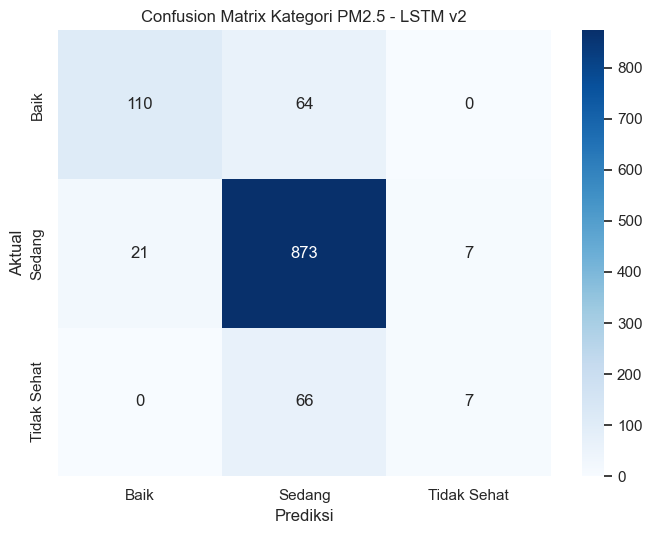

Disimpan: classification_report_lstm_v2.csv + confusion_matrix_lstm_v2.png


In [18]:
ka = pd.Series(yt_final).map(ke_kategori_ispu)
kp = pd.Series(pt_final).map(ke_kategori_ispu)
label_ada = [k for k in URUTAN_KATEGORI_ISPU if k in set(ka) | set(kp)]

akurasi = accuracy_score(ka, kp)
f1_makro = f1_score(ka, kp, average='macro', zero_division=0)
f1_terbobot = f1_score(ka, kp, average='weighted', zero_division=0)
recall_ts = recall_tidak_sehat(yt_final, pt_final)

print(f'Accuracy        : {akurasi:.4f}')
print(f'Macro F1        : {f1_makro:.4f}')
print(f'Weighted F1     : {f1_terbobot:.4f}')
print(f'Recall TidakSehat: {recall_ts:.4f}')

report = classification_report(ka, kp, labels=label_ada, output_dict=True, zero_division=0)
pd.DataFrame(report).T.to_csv(DIR_OUTPUT / 'classification_report_lstm_v2.csv')

matriks = confusion_matrix(ka, kp, labels=label_ada)
plt.figure(figsize=(7, 5.5))
sns.heatmap(matriks, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_ada, yticklabels=label_ada)
plt.title('Confusion Matrix Kategori PM2.5 - LSTM v2')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_lstm_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disimpan: classification_report_lstm_v2.csv + confusion_matrix_lstm_v2.png')


## 17. Visualisasi: Training History, Actual vs Predicted, Residual

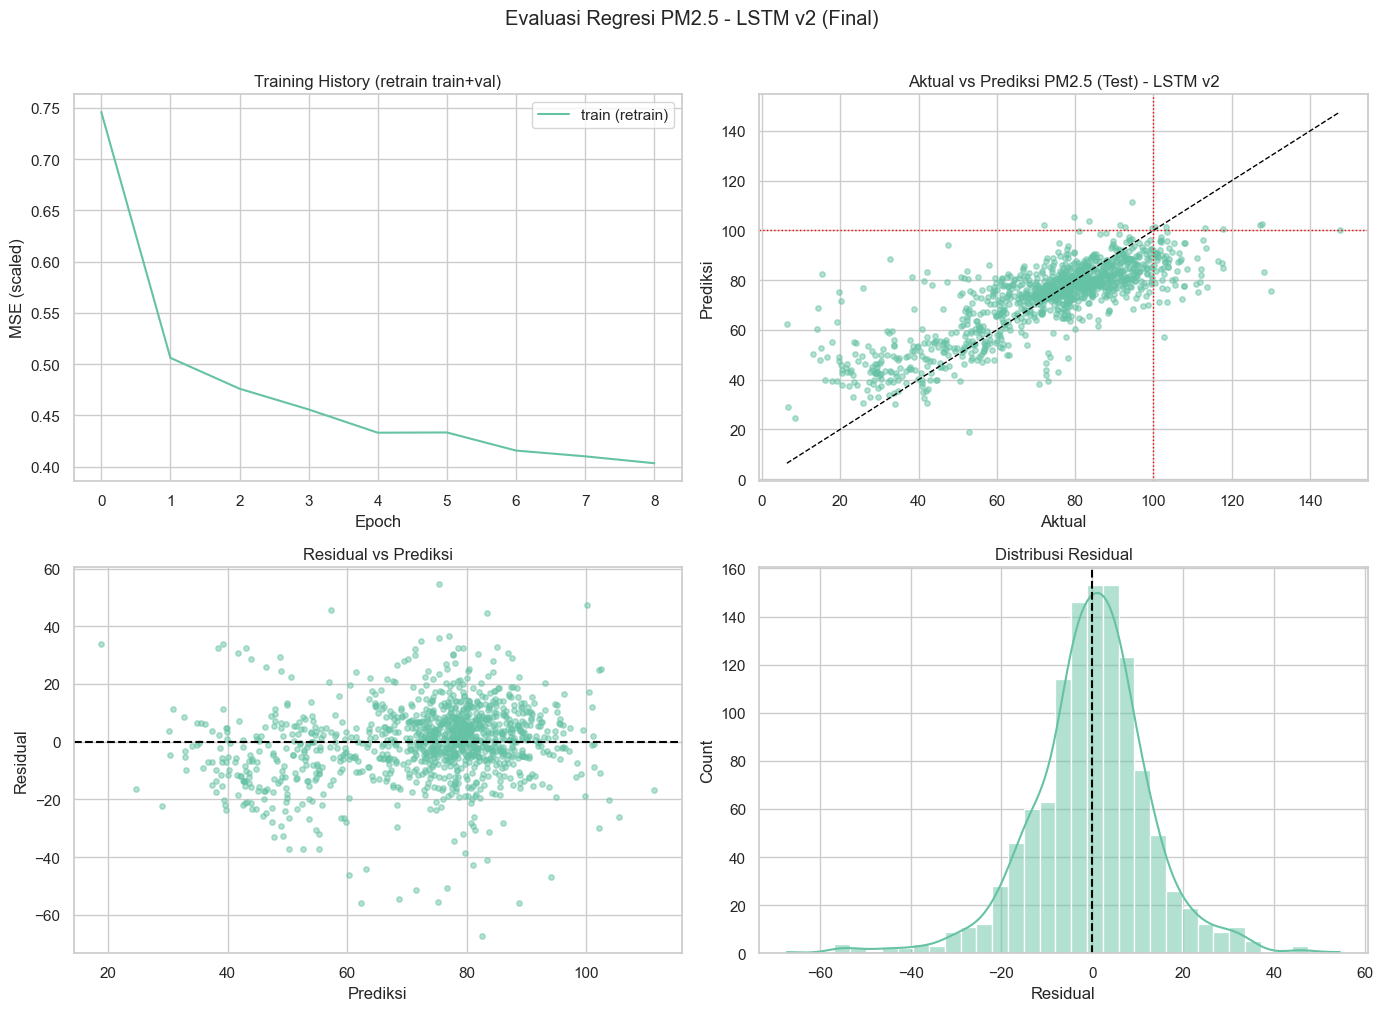

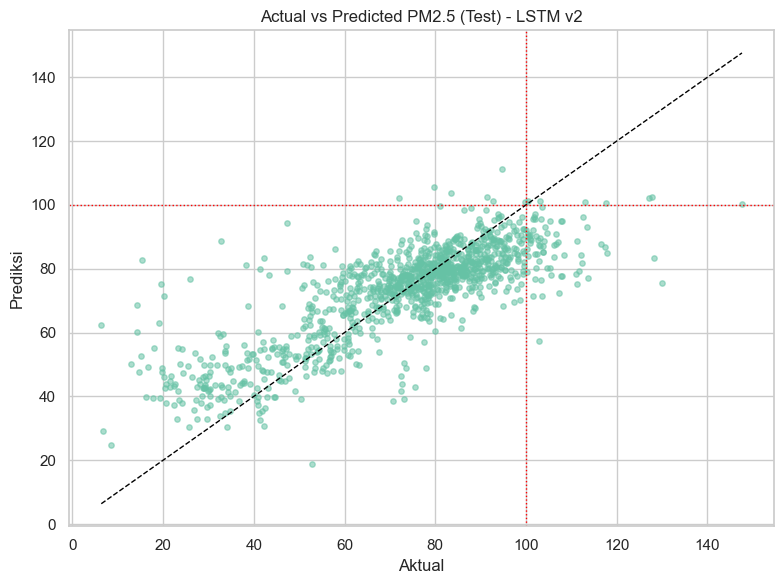

Disimpan: evaluasi_regresi_pm25_lstm_v2.png, actual_vs_predicted_lstm_v2.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Training history retrain final
axes[0, 0].plot(hist_final.history['loss'], label='train (retrain)')
axes[0, 0].set_title('Training History (retrain train+val)')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('MSE (scaled)')
axes[0, 0].legend()

# (b) Actual vs Predicted
axes[0, 1].scatter(yt_final, pt_final, alpha=0.5, s=15)
mn = float(min(yt_final.min(), pt_final.min())); mx = float(max(yt_final.max(), pt_final.max()))
axes[0, 1].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[0, 1].axhline(100, color='red', ls=':', lw=1); axes[0, 1].axvline(100, color='red', ls=':', lw=1)
axes[0, 1].set_title('Aktual vs Prediksi PM2.5 (Test) - LSTM v2')
axes[0, 1].set_xlabel('Aktual'); axes[0, 1].set_ylabel('Prediksi')

# (c) Residual scatter
residual = yt_final - pt_final
axes[1, 0].scatter(pt_final, residual, alpha=0.5, s=15)
axes[1, 0].axhline(0, color='k', ls='--')
axes[1, 0].set_title('Residual vs Prediksi')
axes[1, 0].set_xlabel('Prediksi'); axes[1, 0].set_ylabel('Residual')

# (d) Residual distribution
sns.histplot(residual, kde=True, bins=35, ax=axes[1, 1])
axes[1, 1].axvline(0, color='k', ls='--')
axes[1, 1].set_title('Distribusi Residual')
axes[1, 1].set_xlabel('Residual')

plt.suptitle('Evaluasi Regresi PM2.5 - LSTM v2 (Final)', y=1.01)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'evaluasi_regresi_pm25_lstm_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Standalone actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(yt_final, pt_final, alpha=0.55, s=15)
plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
plt.axhline(100, color='red', ls=':', lw=1); plt.axvline(100, color='red', ls=':', lw=1)
plt.title('Actual vs Predicted PM2.5 (Test) - LSTM v2')
plt.xlabel('Aktual'); plt.ylabel('Prediksi')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'actual_vs_predicted_lstm_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disimpan: evaluasi_regresi_pm25_lstm_v2.png, actual_vs_predicted_lstm_v2.png')


## 18. Simpan Model + Scaler + Metadata

In [20]:
import joblib

path_model = DIR_OUTPUT / 'model_pm25_best_lstm_v2.keras'
model_final.save(path_model)

joblib.dump({
    'scaler_seq': sx_seq_f, 'scaler_static': sx_static_f, 'scaler_y': sy_f,
    'fitur_sequence': FITUR_SEQUENCE, 'fitur_static': FITUR_STATIC,
    'lookback': int(best['lookback']),
}, DIR_OUTPUT / 'scaler_lstm_v2.pkl')

metadata = {
    'model_name': 'LSTM v2 (multi-input, lag/rolling static, leakage-free, optuna-tuned)',
    'algoritma': 'LSTM Multi-Input (Keras Functional API)',
    'arsitektur_terbaik': {
        'lstm_units': list(lstm_units_best),
        'static_units': int(best['static_units']),
        'head_units': int(best['head_units']),
        'dropout': float(best['dropout']),
        'l2': float(best['l2']),
        'lr': float(best['lr']),
        'batchnorm': bool(best['batchnorm']),
        'lookback': int(best['lookback']),
        'batch_size': int(best['batch_size']),
        'n_features_sequence': int(len(FITUR_SEQUENCE)),
        'n_features_static': int(len(FITUR_STATIC)),
    },
    'target': TARGET,
    'fitur_sequence': FITUR_SEQUENCE,
    'fitur_static': FITUR_STATIC,
    'data_path': str(DATA_PATH),
    'split': 'time-based 70/15/15 (train/validation/test)',
    'pemilihan_model': 'lowest val_RMSE via Optuna TPE',
    'model_final_dilatih_pada': 'train + validation (test tidak dipakai untuk training)',
    'epoch_retrain_final': int(epochs_retrain),
    'n_trials_optuna': int(N_TRIALS),
    'rentang_test': [str(pd.Timestamp(tgl_full[m_te].min()).date()),
                     str(pd.Timestamp(tgl_full[m_te].max()).date())],
    'metrik_test_final': {k: round(float(v), 4) for k, v in metrik_final.items()},
    'evaluasi_pm25_tinggi': {k: (round(float(v), 4) if isinstance(v, float) and not np.isnan(v) else v)
                              for k, v in eval_tinggi.items()},
    'metrik_kategori_test': {'accuracy': round(float(akurasi), 4),
                              'macro_f1': round(float(f1_makro), 4),
                              'weighted_f1': round(float(f1_terbobot), 4),
                              'recall_tidak_sehat': round(float(recall_ts), 4)},
    'perbaikan_vs_versi_lama': [
        'A1: tambah 7 fitur lag/rolling PM2.5 (sebagai static input post-LSTM)',
        'A2: multi-input architecture (sequence + static)',
        'A3: median imputation fit hanya di TRAIN (no leakage)',
        'A5: y-scaling konsisten di tuning maupun retrain final',
        'B4: Optuna TPE search luas (lookback/units/dropout/l2/lr/batch/batchnorm)',
    ],
}
(DIR_OUTPUT / 'model_pm25_metadata_lstm_v2.json').write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')

print(f'Model     : {path_model.name}')
print(f'Scaler    : scaler_lstm_v2.pkl')
print(f'Metadata  : model_pm25_metadata_lstm_v2.json')


Model     : model_pm25_best_lstm_v2.keras
Scaler    : scaler_lstm_v2.pkl
Metadata  : model_pm25_metadata_lstm_v2.json


## 19. Perbandingan Akhir: RF vs LSTM Lama vs LSTM v2

Bandingkan dengan RF perbaikan terbaik (dari `evaluasi_random_forest_perbaikan.csv`) dan LSTM perbaikan lama (dari `evaluasi_lstm_perbaikan.csv`).

In [21]:
baris = []

# RF perbaikan
p_rf = DIR_OUTPUT / 'evaluasi_random_forest_perbaikan.csv'
if p_rf.exists():
    rf = pd.read_csv(p_rf).iloc[0]
    baris.append({
        'Model': rf['model'], 'Jenis': 'Random Forest (Perbaikan)',
        'val_RMSE': np.nan,
        'test_MAE': rf['MAE'], 'test_RMSE': rf['RMSE'], 'test_R2': rf['R2'], 'test_MAPE': rf['MAPE'],
        'recall_Tidak_Sehat': rf['recall_Tidak_Sehat'],
        'n_pred_PM25_gt_100': rf['jumlah_prediksi_PM25_gt_100'],
    })

# LSTM perbaikan lama (best by val_RMSE)
p_lstm_lama = DIR_OUTPUT / 'evaluasi_lstm_perbaikan.csv'
if p_lstm_lama.exists():
    ll = pd.read_csv(p_lstm_lama).sort_values('val_RMSE').iloc[0]
    baris.append({
        'Model': ll['model'], 'Jenis': 'LSTM (Perbaikan lama)',
        'val_RMSE': ll['val_RMSE'],
        'test_MAE': ll['MAE'], 'test_RMSE': ll['RMSE'], 'test_R2': ll['R2'], 'test_MAPE': ll['MAPE'],
        'recall_Tidak_Sehat': ll['recall_Tidak_Sehat'],
        'n_pred_PM25_gt_100': ll['jumlah_prediksi_PM25_gt_100'],
    })

# LSTM v2 (final)
baris.append({
    'Model': 'LSTM v2 (multi-input + lag/rolling + Optuna)', 'Jenis': 'LSTM (Perbaikan v2)',
    'val_RMSE': round(float(res_terbaik['val_metrik']['RMSE']), 4),
    'test_MAE': round(metrik_final['MAE'], 4),
    'test_RMSE': round(metrik_final['RMSE'], 4),
    'test_R2': round(metrik_final['R2'], 4),
    'test_MAPE': round(metrik_final['MAPE'], 4),
    'recall_Tidak_Sehat': round(recall_ts, 4),
    'n_pred_PM25_gt_100': int(eval_tinggi['n_prediksi_gt_100']),
})

tabel_akhir = pd.DataFrame(baris)
tabel_akhir.to_csv(DIR_OUTPUT / 'perbandingan_rf_vs_lstm_v2.csv', index=False)
print('Disimpan: perbandingan_rf_vs_lstm_v2.csv')
display(tabel_akhir)


Disimpan: perbandingan_rf_vs_lstm_v2.csv


,Model,Jenis,val_RMSE,test_MAE,test_RMSE,test_R2,test_MAPE,recall_Tidak_Sehat,n_pred_PM25_gt_100
0,Random Forest + Lag/Rolling,Random Forest (Perbaikan),NaN,8.8839,12.3190,0.6722,17.7956,0.0137,10
1,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L7),LSTM (Perbaikan lama),12.1889,9.3741,13.1544,0.6263,18.0419,0.0822,22
2,LSTM v2 (multi-input + lag/rolling + Optuna),LSTM (Perbaikan v2),11.7465,9.4918,13.0884,0.6300,19.1168,0.0959,14


## 20. Kesimpulan

**Yang dikerjakan di notebook ini (sesuai 5 perbaikan dari review):**

1. **A1 — Fitur lag/rolling fair-fight dengan RF.** 7 fitur (`pm25_lag_1/3/7`, `rolling_mean_3/7`, `rolling_max_7`, `rolling_std_7`) ikut sebagai **static features** yang di-concat ke output LSTM. LSTM tidak perlu lagi "menemukan ulang" pola lag dari sequence mentah.
2. **A2 — Multi-input architecture.** Sequence (TARGET + cuaca + siklikal) lewat LSTM; static (lag/rolling + station + musim) lewat Dense; lalu di-concat → head dense → output. Channel sequence tidak lagi diboroskan untuk fitur konstan.
3. **A3 — No leakage imputation.** Median dihitung dari TRAIN saja, lalu dipakai untuk val/test. Ekuivalen dengan apa yang RF dapat via `SimpleImputer` di dalam `ColumnTransformer`.
4. **A5 — y-scaling konsisten.** Skema scaler yang sama dipakai di runner eksperimen dan retrain final, dengan inverse-transform yang nyambung (perbaikan bug A4 dari versi lama).
5. **B4 — Tuning lebih luas.** Optuna TPE atas 11 dimensi (lookback, n_layers, units1/2, static_units, head_units, dropout, l2, lr, batch_size, batchnorm), default 25 trial.

**Cara interpretasi hasil:**
- Bandingkan `test_RMSE` dan `test_R²` LSTM v2 vs RF perbaikan di tabel section 19.
- Cek `recall_Tidak_Sehat` — LSTM diharapkan tetap unggul di sini (sesuai temuan project sebelumnya).
- Kalau LSTM v2 **masih kalah** RF di RMSE meski sudah fair-fight, kesimpulannya: untuk dataset ini (n~6k, horizon H+1, sinyal cuaca lemah) Random Forest memang struktural lebih cocok daripada LSTM. Itu temuan yang valid dan honest untuk laporan akademik.

**Output yang dihasilkan (semua `_lstm_v2`):**
- `hasil_eksperimen_lstm_v2_awal.csv`, `hasil_tuning_lstm_v2_optuna.csv`
- `evaluasi_high_pm25_lstm_v2.csv`, `classification_report_lstm_v2.csv`
- `confusion_matrix_lstm_v2.png`, `evaluasi_regresi_pm25_lstm_v2.png`, `actual_vs_predicted_lstm_v2.png`
- `model_pm25_best_lstm_v2.keras`, `scaler_lstm_v2.pkl`, `model_pm25_metadata_lstm_v2.json`
- `perbandingan_rf_vs_lstm_v2.csv`
